## Measuring the HOG:

#### Parsing COCO to read annotations

In [20]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload to reload all modules before executing code
%autoreload 2

In [21]:
from pathlib import Path 
import os
import numpy as np

import pandas as pd 

from utils import *


imgs = list(Path('/Data_large/marine/Datasets/VENuS/ds_L0/perfect').glob('*.tif'))
print('Listing the number of imgs:')
print(len(imgs))

train_coco_path = '/Data_large/marine/Datasets/VENuS/annotations/perfect/train.json'
val_coco_path = '/Data_large/marine/Datasets/VENuS/annotations/perfect/val.json'
test_coco_path = '/Data_large/marine/Datasets/VENuS/annotations/perfect/test.json'

train_coco = get_coco(train_coco_path)
val_coco = get_coco(val_coco_path)
test_coco = get_coco(test_coco_path)

Listing the number of imgs:
282


In [22]:
annotations1 = train_coco['annotations']
annotations2 = val_coco['annotations']
annotations3 = test_coco['annotations']
annotations = annotations1 + annotations2 + annotations3

images1 = train_coco['images']
images2 = val_coco['images']
images3 = test_coco['images']
images = images1 + images2 + images3

imgidToImage = {x['id']:x['file_name'] for x in images} # dict because this is unique assignment
NameToID = {x['id']:x['file_name'] for x in images}

imgidAndBBox = [(x['image_id'],x['bbox']) for x in annotations] # list because assignment can be multiple
imgidAndBBoxAndType = [(x['image_id'],x['bbox'],x['vessel_type']) for x in annotations] # list because assignment can be multiple
imgidToBBox = convert_to_dict(imgidAndBBox)
filename_bbox = {imgidToImage[x]:y for x,y in imgidToBBox.items()}

nameToPaths = {x.name:x.as_posix() for x in imgs}
PathsToName = {x.as_posix():x.name for x in imgs}

### Creating npy files

In [ ]:
base_outdir = '/Data_large/marine/PythonProjects/MMDET/studies/crops'

for item in imgidAndBBoxAndType:
    name = imgidToImage[item[0]]
    stem = name.split('.')[0]
    path = nameToPaths[name]
    print(path, item[1], item[2])
    bbox = item[1]
    className = item[2]
    
    img = read_tif(file_path=path, band_indices=[1,2,3,4,5,6,7,8,9,10,11,12]) # selected band 1
    # 2. Crop Img using bbox info  3. Save crops in the folders
    stringaBox = str(bbox).replace(' ','').replace('[','').replace(']','').replace(',','_')
    
    for sel_band in [1,2,3,4,5,6,7,8,9,10,11,12]:
        output_dir = f'{base_outdir}/B{sel_band}/{stem}'
        os.makedirs(output_dir, exist_ok=True)
        x, y, width, height = bbox
        cropped_array = img[0][sel_band][y:y+height, x:x+width]
        className = str(className).replace('/','_')
        output_path = f'{output_dir}/{stringaBox}___{className}.npy'
        np.save(output_path.replace(' ','_'), cropped_array)
        

In [23]:
classTranslator = {
    'Bulk Carrier': 'Bulk Carrier',
    'Cement Carrier': 'Bulk Carrier',
    'Heavy Load Carrier': 'Bulk Carrier',

    'General Cargo': 'General Cargo',
    'Cargo': 'General Cargo',

    'Container Ship': 'Container Ships',
    'Vehicles Carrier': 'Container Ships',

    'Tanker': 'Tanker',
    'Tanker - Hazard A (Major)': 'Tanker',
    'Tanker - Hazard C (Minor)': 'Tanker',
    'Tanker - Hazard D (Recognizable)': 'Tanker',
    'Chemical Tanker': 'Tanker',
    'Oil Products Tanker': 'Tanker',
    'Oil': 'Tanker',

    'Other': 'Other',
    'Dredger': 'Other',
    'Fishing': 'Other',
    'Reefer': 'Other',
    'Hopper Dredger': 'Other',
    'Offshore Supply Ship': 'Other',
    'Livestock Carrier': 'Other'
}

#### Helper to list files:

In [24]:
B = {i+1:get_corresponding_B1_files(i+1) for i in range(12)}

### Show vessel in a single band:

46
Number of HOG features with threshold 0.6: 46


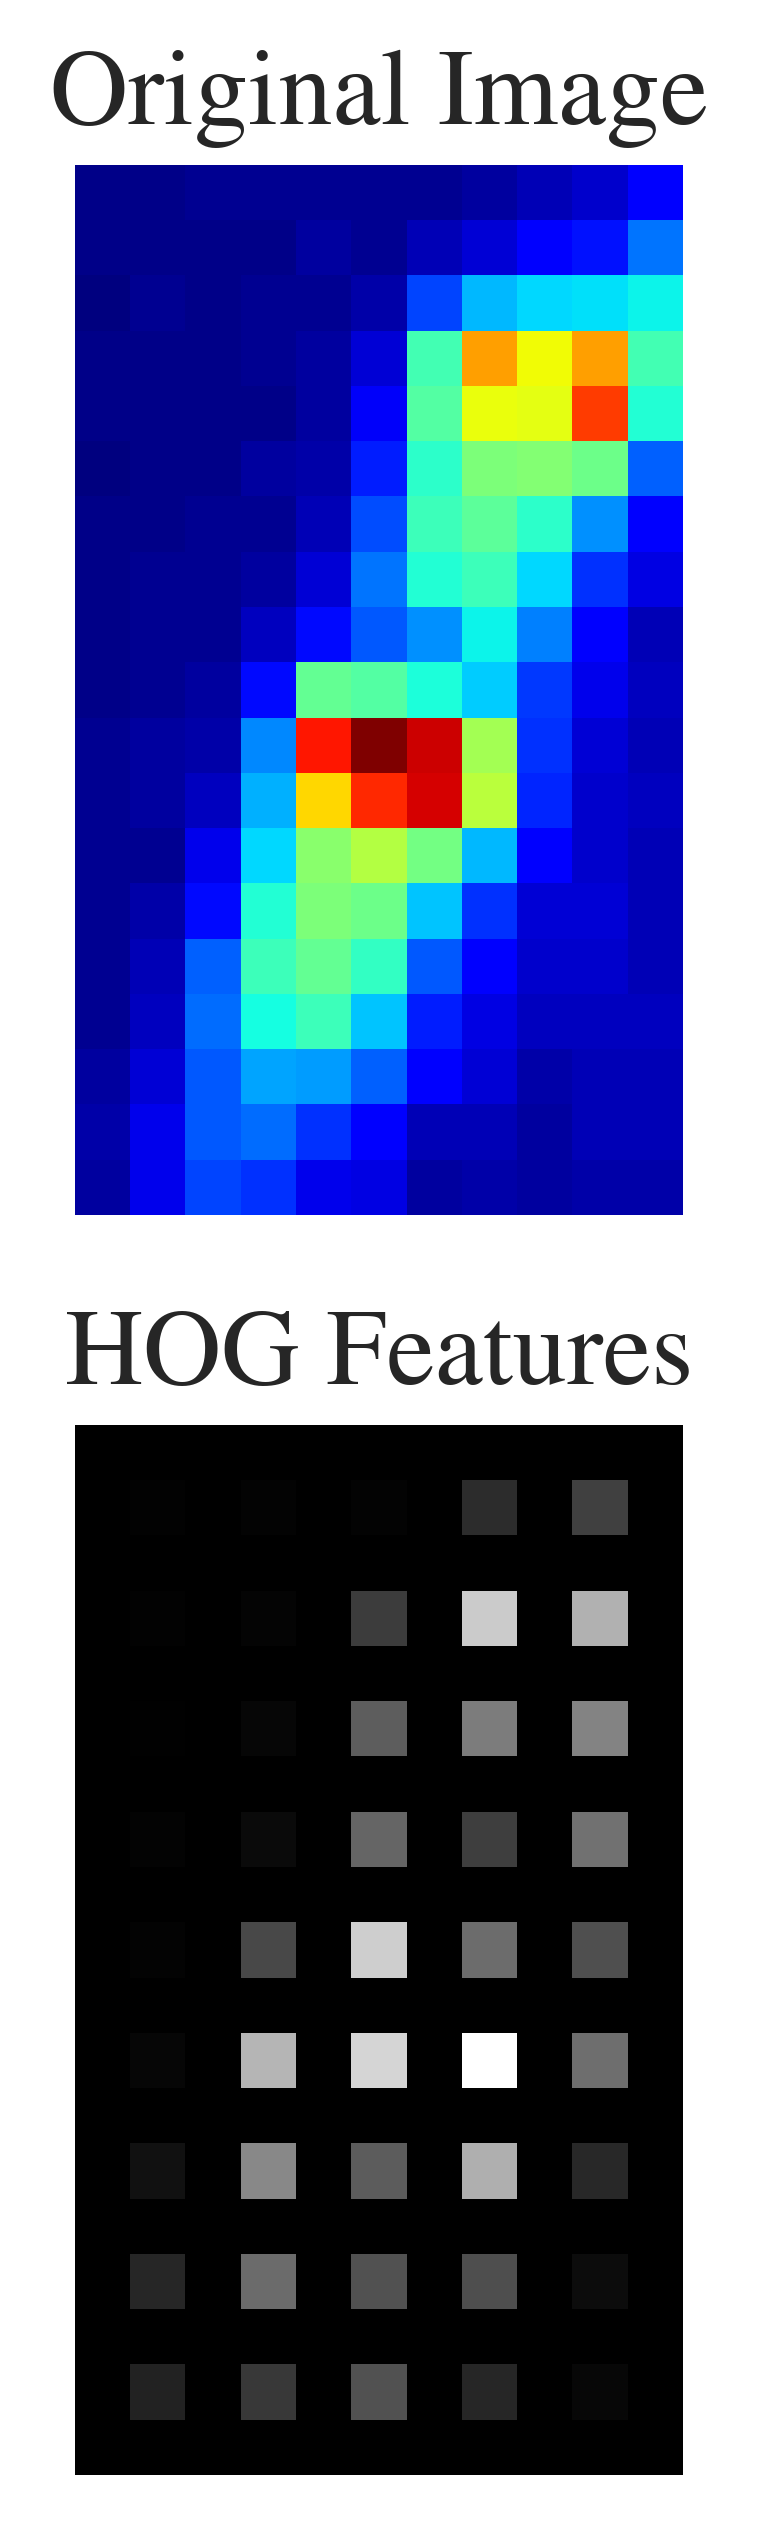

In [25]:
array_in_band = {}
for sel_band in range(1,13,1):
    image_array = np.load(B[sel_band][10])
    array_in_band[sel_band] = image_array

# Set the threshold value
threshold_value = 0.6

BAND = 1
input_img = array_in_band[BAND]


hog_image, num_features = get_hog_and_features(array_in_band[12], threshold_value)

print(num_features)
# plt.imshow(hog_image, cmap='jet')
# plt.imshow(input_img, cmap='jet')
# plt.colorbar(label='Uncalibrated Pixel Intensity')

print(f"Number of HOG features with threshold {threshold_value}: {num_features}")
visualize_hog(image_array, threshold=threshold_value)

#### 12 Bands View:

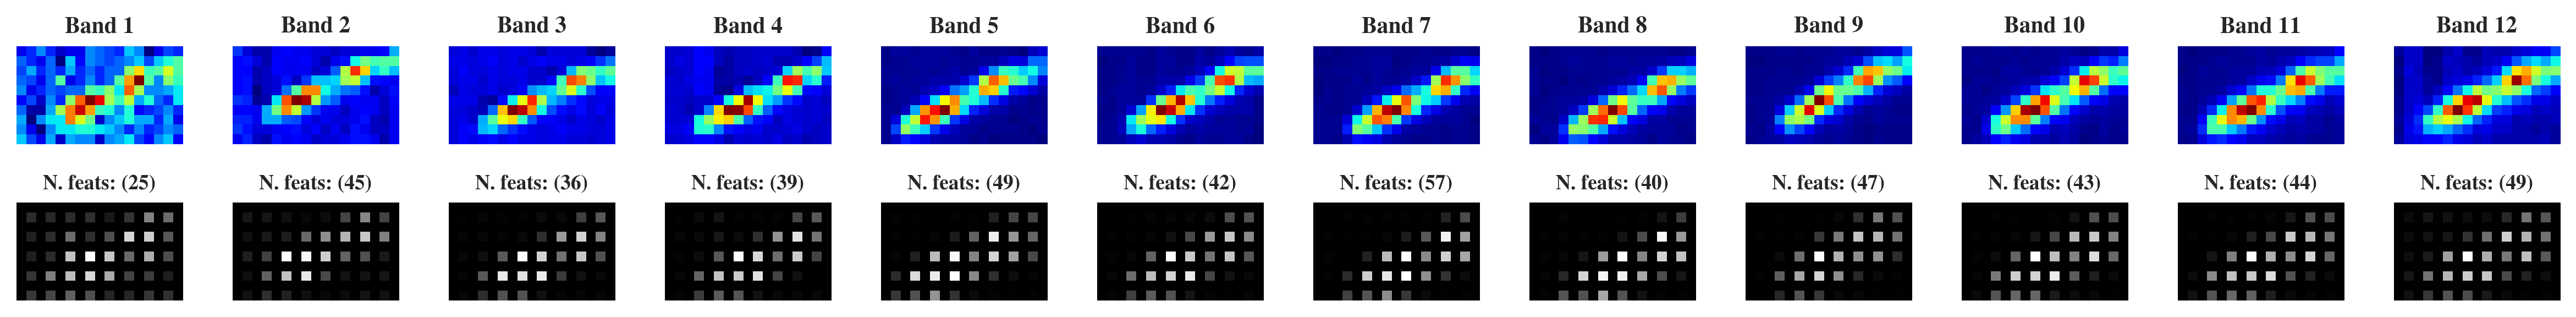

In [26]:
img_id = 23

# Assuming array_in_band is already populated with images for bands 1 to 12
array_in_band = {}
for sel_band in range(1,13,1):
    image_array = np.load(B[sel_band][img_id])
    array_in_band[sel_band] = image_array
    
# Set the threshold value
threshold_value = 0.6

# Plot all bands and their HOG features
plot_bands_and_hog(array_in_band, threshold_value)

#### Computating Hog Features for All:

In [27]:
for threshold_value in [0.5, 0.75, 0.8, 0.9]:
    band_num_hog, stemToHog = process_images(B, threshold_value)
    pd.to_pickle(band_num_hog, f'hog_results/band_num_hog_{threshold_value}.pkl')
    pd.to_pickle(stemToHog, f'hog_results/stemToHog_{threshold_value}.pkl')

Processing images:  15%|█▍        | 569/3826 [01:22<05:30,  9.87it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B1/ASH_L0_08109_20190212_MultiLayer_mask_OK/145_461_-10_-9___nan.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B2/ASH_L0_08109_20190212_MultiLayer_mask_OK/145_461_-10_-9___nan.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B3/ASH_L0_08109_20190212_MultiLayer_mask_OK/145_461_-10_-9___nan.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B4/ASH_L0_08109_20190212_MultiLayer_mask_OK/145_461_-10_-9___nan.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B5/ASH_L0_08109_20190212_MultiLayer_mask_OK/145_461_-10_-9___nan.npy: index 0 is out of bounds for axis 0 with size 0
Error processing /Data_large/marine/PythonProjects/MMDE

Processing images:  16%|█▋        | 628/3826 [01:31<05:47,  9.21it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B1/ASH_L0_16229_20200825_MultiLayer_mask_OK/-2_1569_25_22___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B2/ASH_L0_16229_20200825_MultiLayer_mask_OK/-2_1569_25_22___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B3/ASH_L0_16229_20200825_MultiLayer_mask_OK/-2_1569_25_22___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B4/ASH_L0_16229_20200825_MultiLayer_mask_OK/-2_1569_25_22___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B5/ASH_L0_16229_20200825_MultiLayer_mask_OK/-2_1569_25_22___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error

Processing images:  78%|███████▊  | 2971/3826 [07:04<03:23,  4.20it/s]

...

Processing images:  78%|███████▊  | 2971/3826 [06:32<03:17,  4.34it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B1/ASH_L0_10139_20190702_MultiLayer_mask_OK/-4_1117_29_20___nan.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B2/ASH_L0_10139_20190702_MultiLayer_mask_OK/-4_1117_29_20___nan.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B3/ASH_L0_10139_20190702_MultiLayer_mask_OK/-4_1117_29_20___nan.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B4/ASH_L0_10139_20190702_MultiLayer_mask_OK/-4_1117_29_20___nan.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B5/ASH_L0_10139_20190702_MultiLayer_mask_OK/-4_1117_29_20___nan.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/stu

Processing images:  86%|████████▋ | 3307/3826 [07:12<00:55,  9.31it/s]

Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B1/ASH_L0_16258_20200827_MultiLayer_mask_OK/-1_1590_33_8___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B2/ASH_L0_16258_20200827_MultiLayer_mask_OK/-1_1590_33_8___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B3/ASH_L0_16258_20200827_MultiLayer_mask_OK/-1_1590_33_8___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B4/ASH_L0_16258_20200827_MultiLayer_mask_OK/-1_1590_33_8___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error processing /Data_large/marine/PythonProjects/MMDET/studies/crops/B5/ASH_L0_16258_20200827_MultiLayer_mask_OK/-1_1590_33_8___Container_Ship.npy: index 0 is out of bounds for axis 1 with size 0
Error proc

Processing images: 100%|██████████| 3826/3826 [08:16<00:00,  7.71it/s]


## Plotting the HOG:

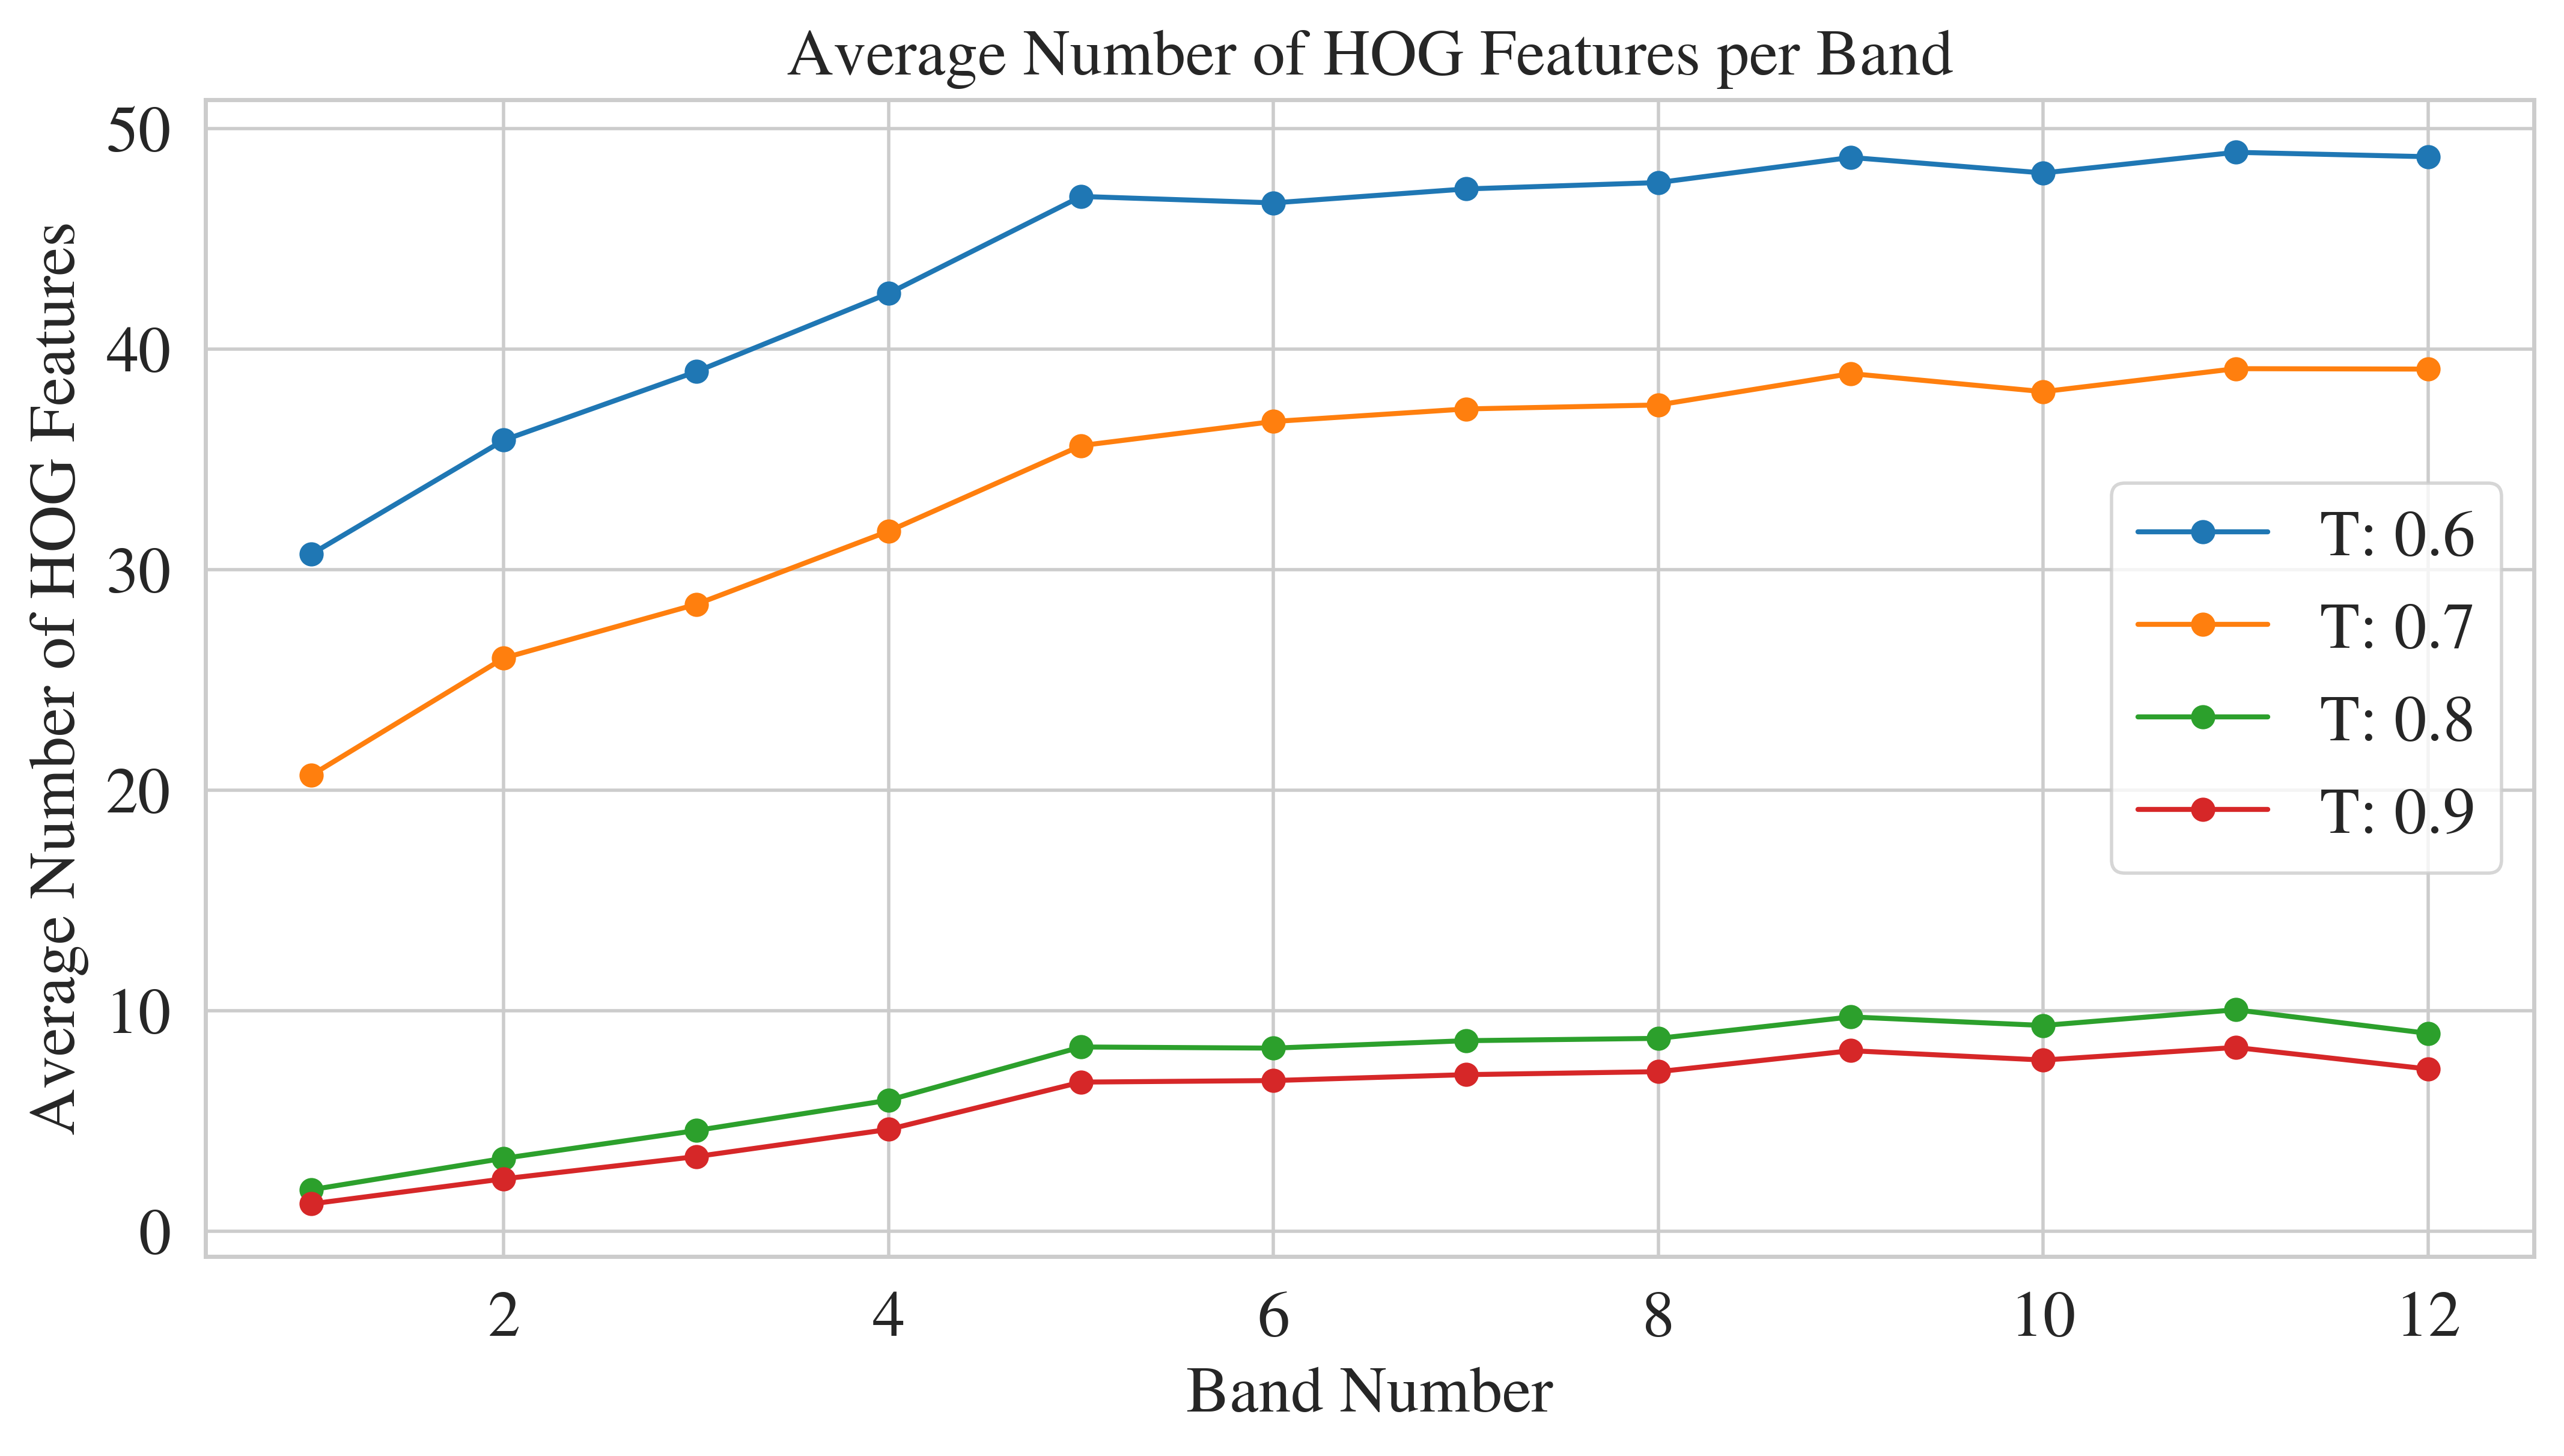

In [28]:
from pathlib import Path 
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from style import set_style



set_style(scale_factor=1.2)

plt.figure(figsize=(10,5))



for threshold_value in [0.6, 0.7, 0.8, 0.9]:
    band_num_hog = pd.read_pickle(f'hog_results/band_num_hog_{threshold_value}.pkl')
    df = pd.DataFrame(band_num_hog)
    # calculate average number of HOG features per band in df
    avgs = [df[i].mean() for i in range(1,13)]

    plt.plot(range(1,13), avgs, marker='o', label=f'T: {threshold_value}')
    plt.xlabel('Band Number')
    plt.ylabel('Average Number of HOG Features')
    plt.title('Average Number of HOG Features per Band')
    plt.legend()

plt.show()
    


In [ ]:
# threshold_value = 0.75
# band_num_hog = pd.read_pickle(f'band_num_hog_{threshold_value}.pkl')
# plot_hog_features(band_num_hog)

In [ ]:
# threshold_value = 0.55
# band_num_hog = pd.read_pickle(f'band_num_hog_{threshold_value}.pkl')
# plot_hog_features(band_num_hog)